# Actividad 1 - Interpretabilidad de modelos

**Materia:** Análisis de Datos 2 - 4B2026  
**Autor:** Franco Curcho  

## 1. Preparación del entorno

La notebook necesita `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn` y `shap`. Si SHAP no está instalado, puede habilitarse y ejecutarse la siguiente línea:

```python
%pip install -q shap
```


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TARGET = "salary_in_usd"


/home/franc/.venvs/add2-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y control básico de los datos

Se verifican estructura, faltantes y duplicados, ya que pueden afectar la evaluación y la interpretabilidad.


In [ ]:
DATA_PATH = Path("ds_salaries.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("upload/ds_salaries.csv")  

df_raw = pd.read_csv(DATA_PATH)

print(f"Dimensión original: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Valores faltantes: {int(df_raw.isna().sum().sum())}")
print(f"Filas exactamente duplicadas: {int(df_raw.duplicated().sum()):,}")
display(df_raw.head())


Dimensión original: 3,755 filas x 11 columnas
Valores faltantes: 0
Filas exactamente duplicadas: 1,171


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
# Se eliminan duplicados exactos antes de dividir los datos para impedir que una misma
df = df_raw.drop_duplicates().reset_index(drop=True)

resumen_variables = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "faltantes": df.isna().sum(),
})

print(f"Filas utilizadas: {len(df):,}")
display(resumen_variables)


Filas utilizadas: 2,584


,tipo,valores_unicos,faltantes
work_year,int64,4,0
experience_level,str,4,0
employment_type,str,4,0
job_title,str,93,0
salary,int64,815,0
salary_currency,str,20,0
salary_in_usd,int64,1035,0
employee_residence,str,78,0
remote_ratio,int64,3,0
company_location,str,72,0


### Decisión sobre los duplicados

Se encontraron **1.171 filas exactamente duplicadas** (31,2% del archivo original). Si bien esto puede deberse a registros idénticos donde no hubo error en la carga de datos. Se eliminan porque puede influir negativamente en la predicción debido a la presencia de datos idénticos.


## 3. Modelo original con todas las variables disponibles

La variable objetivo es `salary_in_usd`. Se emplean las diez columnas restantes como predictores. Las variables categóricas se codifican mediante *one-hot encoding*.

Se usa una división 80/20 y `RandomForestRegressor` con sus hiperparámetros por defecto; únicamente se fija `random_state=42` para reproducibilidad.


In [ ]:
def build_pipeline(X):
    categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
    numerical = X.select_dtypes(include="number").columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
            ("numerical", "passthrough", numerical),
        ],
        verbose_feature_names_out=True,
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE)),
    ])
    return pipeline, categorical, numerical


def regression_metrics(y_true, y_pred):
    return {
        "MAE (USD)": mean_absolute_error(y_true, y_pred),
        "RMSE (USD)": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

model_all, categorical_all, numerical_all = build_pipeline(X_train)
model_all.fit(X_train, y_train)
pred_all = model_all.predict(X_test)

# Baseline: siempre predice la mediana del conjunto de entrenamiento.
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

metrics_original = regression_metrics(y_test, pred_all)
metrics_baseline = regression_metrics(y_test, pred_baseline)

performance_initial = pd.DataFrame(
    [metrics_baseline, metrics_original],
    index=["Baseline (mediana)", "Random Forest original"],
)
display(performance_initial.style.format({"MAE (USD)": "{:,.0f}", "RMSE (USD)": "{:,.0f}", "R2": "{:.3f}"}))


,MAE (USD),RMSE (USD),R2
Baseline (mediana),"53,555","66,195",-0.002
Random Forest original,"2,146","15,091",0.948


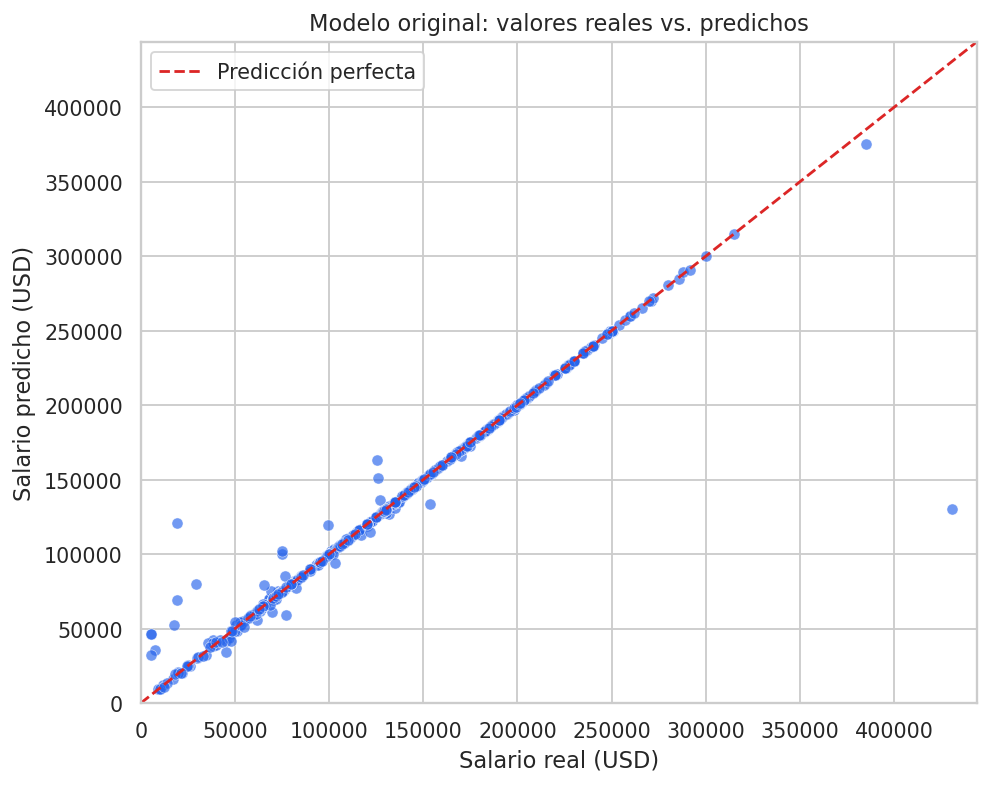

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(y_test, pred_all, alpha=0.65, s=35, color="#2563EB", edgecolor="white", linewidth=0.35)
limits = [0, max(y_test.max(), pred_all.max()) * 1.03]
ax.plot(limits, limits, "--", color="#DC2626", linewidth=1.5, label="Predicción perfecta")
ax.set(xlabel="Salario real (USD)", ylabel="Salario predicho (USD)",
       title="Modelo original: valores reales vs. predichos", xlim=limits, ylim=limits)
ax.legend()
plt.tight_layout()
plt.show()


### Evaluación breve

El modelo original alcanza **MAE = USD 2.146**, **RMSE = USD 15.091** y **$R^2 = 0{,}948$**, muy por encima de la línea base. La diferencia marcada entre MAE y RMSE muestra que existen algunos errores grandes, y un desempeño tan alto en salarios heterogéneos requiere auditar posibles atajos antes de considerarlo válido.


## 4. Diagnóstico global mediante PFI

Se utiliza PFI sobre las columnas originales, un valor grande y positivo indica que el modelo depende mucho de esa variable y si es negativo, lo contrario.

,variable,aumento_mae,desvio
0,salary,"70,297","2,140"
1,salary_currency,"11,515","1,107"
2,company_location,267,34
3,employee_residence,194,22
4,work_year,47,23
5,employment_type,19,28
6,remote_ratio,9,5
7,company_size,8,11
8,experience_level,0,17
9,job_title,-13,21


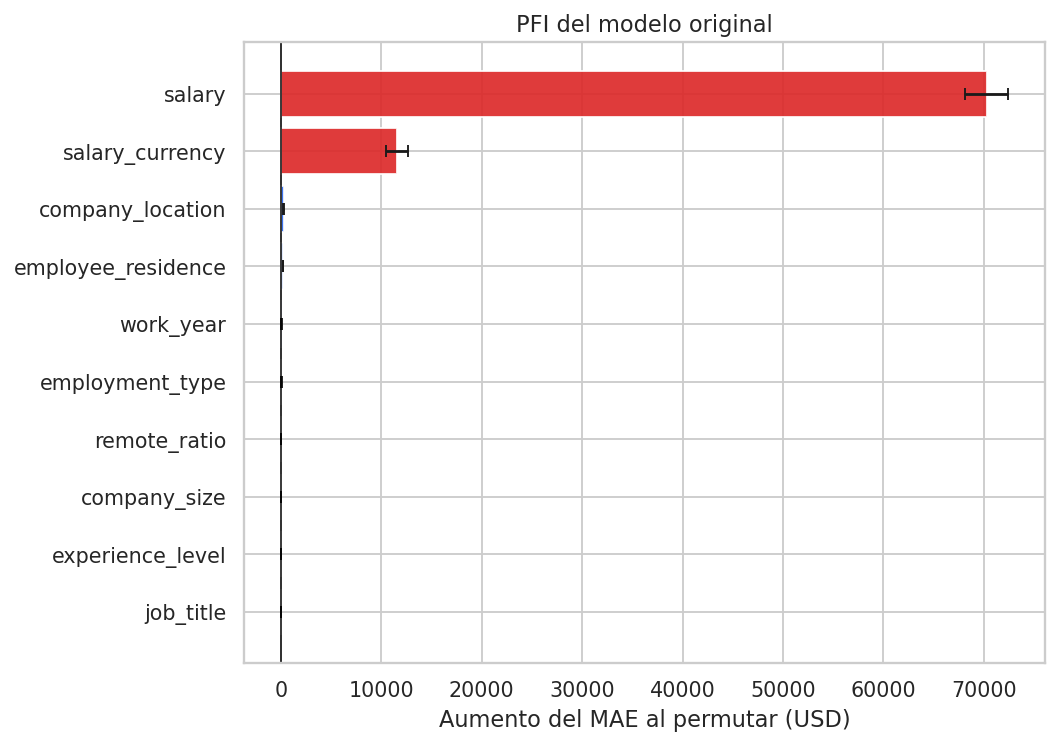

In [ ]:
def compute_pfi(model, X_test, y_test, repeats=15):
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=repeats,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    return (
        pd.DataFrame({
            "variable": X_test.columns,
            "aumento_mae": result.importances_mean,
            "desvio": result.importances_std,
        })
        .sort_values("aumento_mae", ascending=False)
        .reset_index(drop=True)
    )


def plot_pfi(table, title):
    ordered = table.sort_values("aumento_mae")
    colors = ["#DC2626" if x > 10_000 else "#2563EB" for x in ordered["aumento_mae"]]
    fig, ax = plt.subplots(figsize=(8, 5.7))
    ax.barh(ordered["variable"], ordered["aumento_mae"],
            xerr=ordered["desvio"], color=colors, alpha=0.9, capsize=3)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(xlabel="Aumento del MAE al permutar (USD)", ylabel="", title=title)
    plt.tight_layout()
    plt.show()


pfi_original = compute_pfi(model_all, X_test, y_test)
display(pfi_original.style.format({"aumento_mae": "{:,.0f}", "desvio": "{:,.0f}"}))
plot_pfi(pfi_original, "PFI del modelo original")


### Interpretación global

- Al permutar `salary`, el MAE aumenta aproximadamente **USD 70.297**.
- Al permutar `salary_currency`, aumenta otros **USD 11.515**.
- Ninguna de las demás variables supera un aumento de **USD 267**.
- `job_title` y `experience_level`, que deberían ser relevantes para un salario, aparecen prácticamente anuladas.

Esto  significa que el modelo encontró un atajo mucho más directo: `salary_in_usd` es la conversión a dólares de `salary`, determinada por `salary_currency`. Por lo tanto, estas dos columnas contienen información derivada del propio objetivo y constituyen data leakage para una tarea predictiva.


## 5. Diagnóstico local mediante SHAP

Se seleccionan la predicción más baja y la más alta del conjunto de prueba para contrastar dos comportamientos. Un SHAP positivo empuja la predicción hacia arriba; uno negativo, hacia abajo.

In [ ]:
def transformed_feature_groups(model, categorical, numerical):
    preprocessor = model.named_steps["preprocessor"]
    encoder = preprocessor.named_transformers_["categorical"]

    groups = []
    for variable, categories in zip(categorical, encoder.categories_):
        groups.extend([variable] * len(categories))
    groups.extend(numerical)

    transformed_names = preprocessor.get_feature_names_out().tolist()
    assert len(groups) == len(transformed_names)
    return transformed_names, groups


X_test_transformed = model_all.named_steps["preprocessor"].transform(X_test)
rf = model_all.named_steps["model"]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_transformed)
base_value = float(np.asarray(explainer.expected_value).ravel()[0])
feature_names, feature_groups = transformed_feature_groups(
    model_all, categorical_all, numerical_all
)

low_pos = int(np.argmin(pred_all))
high_pos = int(np.argmax(pred_all))


def aggregate_local_shap(position):
    local = pd.DataFrame({
        "variable": feature_groups,
        "shap": shap_values[position],
    })
    local = local.groupby("variable", as_index=False)["shap"].sum()
    local["abs_shap"] = local["shap"].abs()
    return local.sort_values("abs_shap", ascending=False).reset_index(drop=True)


def case_summary(position, label):
    return pd.Series({
        "caso": label,
        "índice": X_test.index[position],
        "salario real": y_test.iloc[position],
        "predicción": pred_all[position],
        "error absoluto": abs(y_test.iloc[position] - pred_all[position]),
    })


local_low = aggregate_local_shap(low_pos)
local_high = aggregate_local_shap(high_pos)

cases = pd.DataFrame([
    case_summary(low_pos, "Predicción baja"),
    case_summary(high_pos, "Predicción alta"),
]).set_index("caso")
display(cases.style.format({"salario real": "USD {:,.0f}", "predicción": "USD {:,.0f}", "error absoluto": "USD {:,.0f}"}))


,índice,salario real,predicción,error absoluto
caso,,,,
Predicción baja,1361,"USD 10,000","USD 9,653",USD 347
Predicción alta,890,"USD 385,000","USD 375,109","USD 9,891"


Valor base: USD 133,635
Base + suma SHAP: USD 9,653
Predicción del modelo: USD 9,653


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
valor,2022,SE,FT,3D Computer Vision Researcher,10000,USD,CA,50,AL,S


,variable,shap
0,salary,"-125,611"
1,salary_currency,"1,804"
2,employee_residence,-95
3,company_location,-41
4,work_year,-35
5,company_size,-23
6,experience_level,20
7,remote_ratio,-18
8,job_title,16
9,employment_type,2


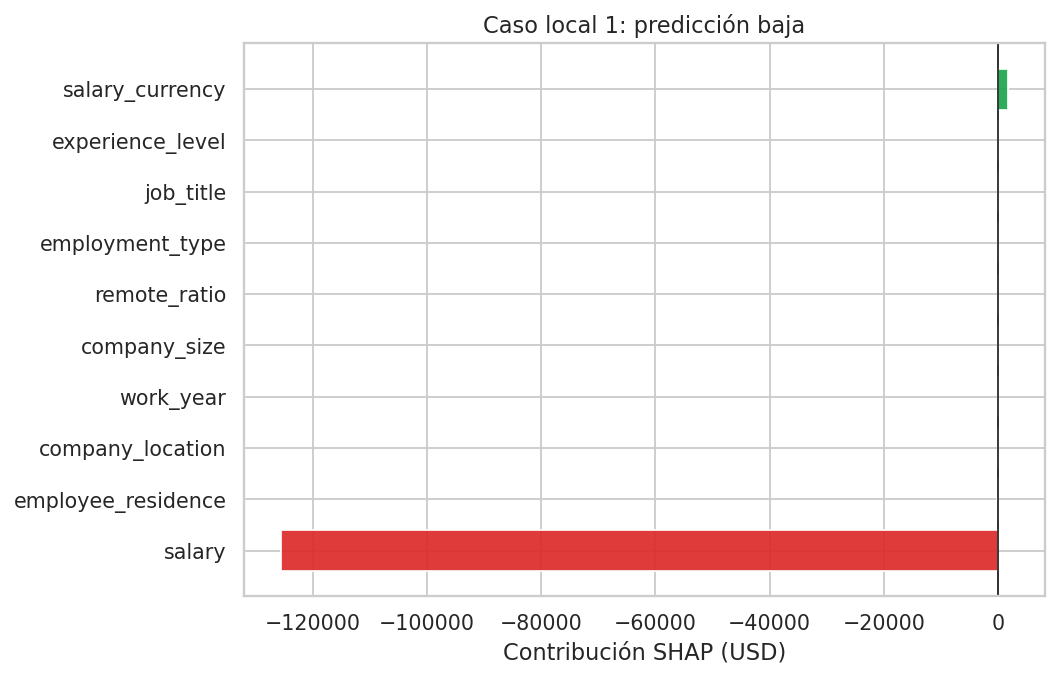

In [ ]:
def plot_local_shap(table, title, top_n=10):
    shown = table.head(top_n).sort_values("shap")
    colors = ["#DC2626" if value < 0 else "#16A34A" for value in shown["shap"]]
    fig, ax = plt.subplots(figsize=(8, 5.2))
    ax.barh(shown["variable"], shown["shap"], color=colors, alpha=0.9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(xlabel="Contribución SHAP (USD)", ylabel="", title=title)
    plt.tight_layout()
    plt.show()


display(pd.DataFrame({"valor": X_test.iloc[low_pos]}).T)
display(local_low[["variable", "shap"]].style.format({"shap": "{:,.0f}"}))
plot_local_shap(local_low, "Caso local 1: predicción baja")

reconstructed_low = base_value + local_low["shap"].sum()
print(f"Valor base: USD {base_value:,.0f}")
print(f"Base + suma SHAP: USD {reconstructed_low:,.0f}")
print(f"Predicción del modelo: USD {pred_all[low_pos]:,.0f}")


### Caso local 1 - Predicción baja

- **Observación:** *3D Computer Vision Researcher*, nivel senior, salario declarado de USD 10.000.
- **Predicción:** USD 9.653; valor real: USD 10.000; error absoluto: USD 347.
- El valor base del modelo es cercano a **USD 133.635**.
- `salary` aporta aproximadamente **-USD 125.611**, empujando casi por sí sola la predicción hacia el valor observado.
- `salary_currency = USD` aporta alrededor de **+USD 1.804**. Las demás variables tienen contribuciones menores a USD 100.

La explicación local es coherente con la PFI: el modelo casi no razona a partir del puesto, la experiencia o la modalidad; reproduce la variable salarial filtrada.


Valor base: USD 133,635
Base + suma SHAP: USD 375,109
Predicción del modelo: USD 375,109


,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size
valor,2023,SE,FT,Data Analyst,385000,USD,US,0,US,M


,variable,shap
0,salary,"228,813"
1,salary_currency,"13,529"
2,work_year,-942
3,remote_ratio,-470
4,company_location,237
5,employee_residence,195
6,job_title,154
7,company_size,-84
8,experience_level,30
9,employment_type,12


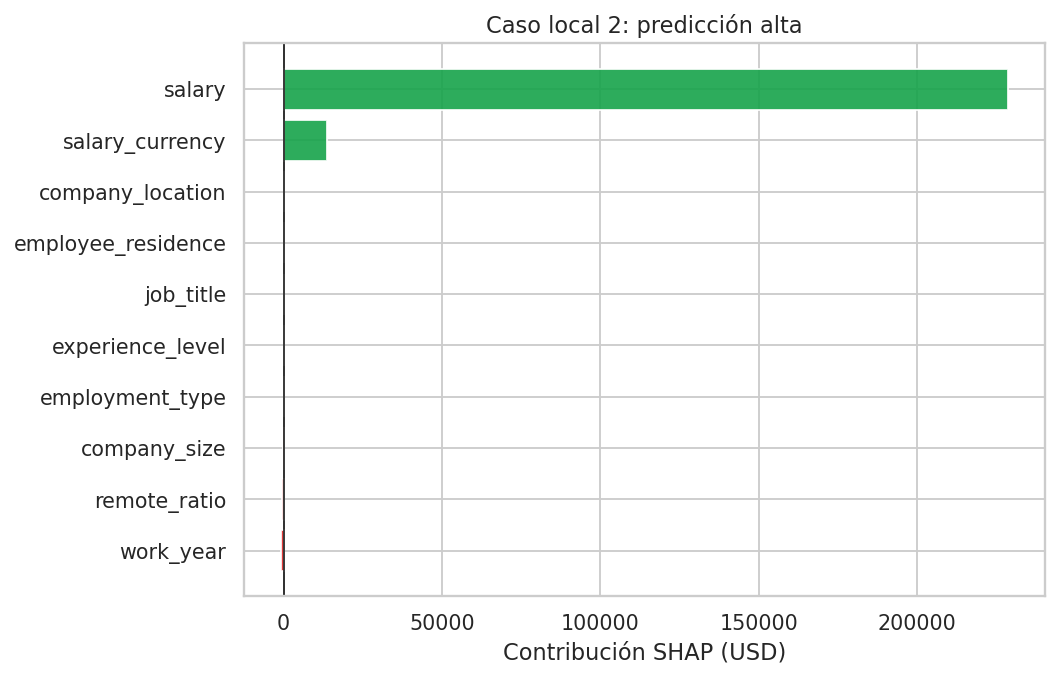

In [ ]:
display(pd.DataFrame({"valor": X_test.iloc[high_pos]}).T)
display(local_high[["variable", "shap"]].style.format({"shap": "{:,.0f}"}))
plot_local_shap(local_high, "Caso local 2: predicción alta")

reconstructed_high = base_value + local_high["shap"].sum()
print(f"Valor base: USD {base_value:,.0f}")
print(f"Base + suma SHAP: USD {reconstructed_high:,.0f}")
print(f"Predicción del modelo: USD {pred_all[high_pos]:,.0f}")


### Caso local 2 - Predicción alta

- **Observación:** *Data Analyst*, nivel senior, salario declarado de USD 385.000.
- **Predicción:** USD 375.109; valor real: USD 385.000; error absoluto: USD 9.891.
- `salary` aporta aproximadamente **+USD 228.813** y `salary_currency` otros **+USD 13.529**.
- El resto de las variables aporta menos de USD 1.000 cada una; incluso el título `Data Analyst` contribuye solo cerca de +USD 154.

Nuevamente, la dirección de los aportes es coherente con la PFI. El salario alto no se explica principalmente por el puesto o la experiencia, sino porque el modelo ve una versión casi directa del resultado que debe predecir.


## 6. Corrección del leakage y reentrenamiento

Se eliminan `salary` y `salary_currency`.


In [ ]:
LEAKAGE_COLUMNS = ["salary", "salary_currency"]
X_clean = df.drop(columns=[TARGET, *LEAKAGE_COLUMNS])

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y, test_size=0.20, random_state=RANDOM_STATE
)

model_clean, categorical_clean, numerical_clean = build_pipeline(X_train_clean)
model_clean.fit(X_train_clean, y_train_clean)
pred_clean = model_clean.predict(X_test_clean)

metrics_clean = regression_metrics(y_test_clean, pred_clean)
comparison = pd.DataFrame(
    [metrics_baseline, metrics_original, metrics_clean],
    index=["Baseline (mediana)", "RF original (con leakage)", "RF corregido (sin leakage)"],
)
display(comparison.style.format({"MAE (USD)": "{:,.0f}", "RMSE (USD)": "{:,.0f}", "R2": "{:.3f}"}))


,MAE (USD),RMSE (USD),R2
Baseline (mediana),"53,555","66,195",-0.002
RF original (con leakage),"2,146","15,091",0.948
RF corregido (sin leakage),"38,577","52,595",0.368


,variable,aumento_mae,desvio
0,employee_residence,"11,760","1,170"
1,experience_level,"7,469",974
2,job_title,"3,552",818
3,company_location,776,204
4,work_year,653,485
5,remote_ratio,172,278
6,employment_type,120,150
7,company_size,-307,308


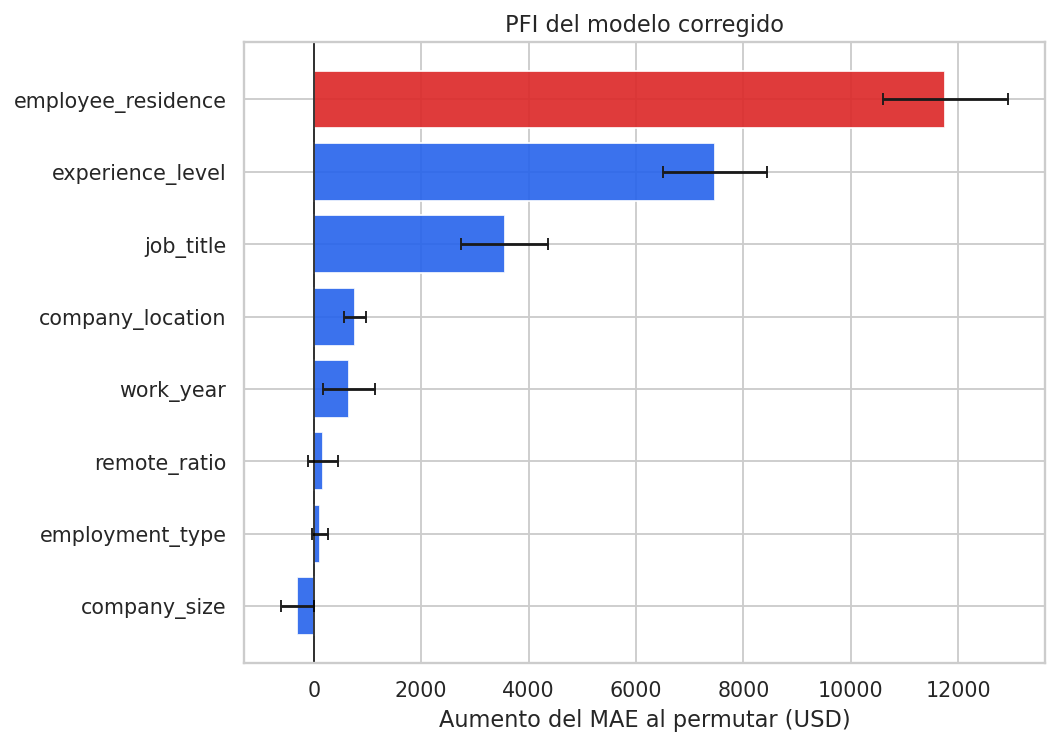

In [ ]:
pfi_clean = compute_pfi(model_clean, X_test_clean, y_test_clean)
display(pfi_clean.style.format({"aumento_mae": "{:,.0f}", "desvio": "{:,.0f}"}))
plot_pfi(pfi_clean, "PFI del modelo corregido")


### Comparación

Al remover el leakage:

- El **MAE** aumenta de USD 2.146 a **USD 38.577**.
- El **RMSE** aumenta de USD 15.091 a **USD 52.595**.
- El **$R^2$** baja de 0,948 a **0,368**.

La caída no indica que la corrección haya empeorado un modelo válido. Expone la dificultad real de predecir salarios sin conocer el salario original. Aun así, el modelo corregido mejora la línea base de la mediana (MAE USD 53.555) y conserva capacidad predictiva moderada.

La PFI corregida resulta más razonable: `employee_residence`, `experience_level` y `job_title` pasan a ser las variables principales. 


## 7. Auditoría del comportamiento del modelo

### Hallazgo 1 - Data leakage 

- Se halló Data leakage provocadas por las columnas `salary` y `salary_currency`. Si bien a primera vista el modelo tenía resultados "excelentes" no eran reales ya que la variable target se respaldaba de estas dos columnas que estaban afectando el modelo.


### Hallazgo 2 - Columnas infravaloradas para la predicción final

- **Evidencia:** con leakage, `job_title` y `experience_level` tienen PFI cercana a cero  también. Sin leakage, sus aumentos del MAE son aproximadamente USD 3.552 y USD 7.469, respectivamente. Y esto está mal, puesto y nivel de experiencia laboral son datos que nos dan una información muy importante de cuanto gana un empleado.


### Hallazgo 3 - Redundancia entre variables geográficas

- **Evidencia:** `employee_residence` y `company_location` coinciden en **96,3%** de las observaciones. En el modelo corregido, PFI concentra mucha más importancia en residencia (USD 11.760) que en ubicación de la empresa (USD 776). En este hallazgo, considero que son dos variables que deberían tener una importancia similar al ser tan parecidas en la mayoría de los casos.



## 8. Conclusión

El modelo original parecía excelente, pero PFI y SHAP mostraron que su desempeño se apoyaba casi por completo en una filtración del objetivo. Las dos técnicas fueron consistentes:

- **PFI** detectó globalmente una dependencia desproporcionada de `salary` y `salary_currency`.
- **SHAP** confirmó localmente que esas variables explicaban casi toda cada predicción, tanto baja como alta.
- El reentrenamiento sin leakage produjo métricas más modestas, pero un comportamiento sustantivamente más razonable: residencia, experiencia y puesto pasaron a dominar la importancia.

La principal conclusión de auditoría es que una métrica alta no garantiza un modelo válido. Antes de optimizarlo, es necesario comprobar que sus predictores sean legítimos para el momento y el objetivo de la predicción.

